In [30]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [31]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras import layers 

In [32]:
(X_train , y_train) , (X_test , y_test) = keras.datasets.mnist.load_data()

In [33]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Pixel value range:", X_train.min(), "to", X_train.max())

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)
Pixel value range: 0 to 255


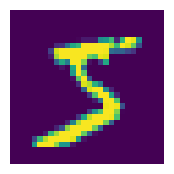

In [34]:
plt.figure(figsize=(2,2))
plt.imshow(X_train[0])
plt.axis("off")
plt.show()

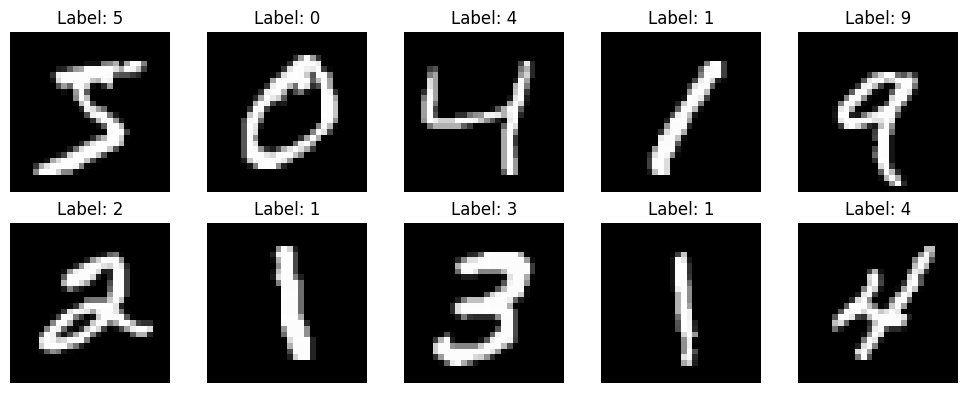

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

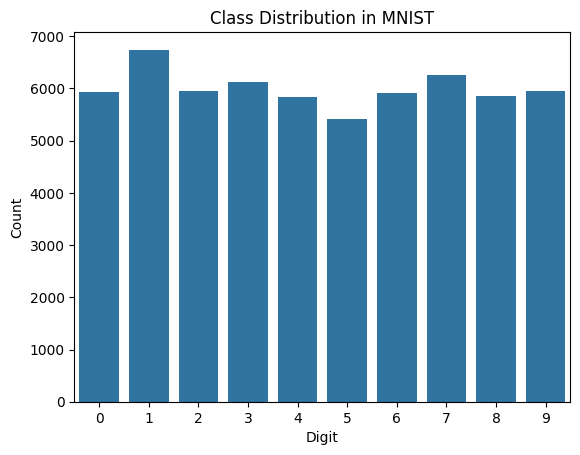

{np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}


In [36]:

unique, counts = np.unique(y_train, return_counts=True)
sns.barplot(x=unique, y=counts)
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('Class Distribution in MNIST')
plt.show()

print(dict(zip(unique, counts)))

In [37]:
print(np.isnan(X_train).sum())  # NaN check
print((X_train.sum(axis=(1,2)) == 0).sum())  # kitni images poori black hain (potentially corrupt)

0
0


In [38]:
# X_train_flat = X_train.reshape(X_train.shape[0], 28*28)  # (60000, 784)
# X_test_flat = X_test.reshape(X_test.shape[0], 28*28)

# print(X_train_flat.shape)  # (60000, 784)

In [39]:
# Normalizing 

X_train = X_train/255
X_test = X_test/255

In [40]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("y_train[0]:", y_train[0])

X_train: (60000, 28, 28)
y_train: (60000,)
y_train[0]: 5


In [41]:
# from tensorflow.keras.utils import to_categorical

# y_train_onehot = to_categorical(y_train, num_classes=10)
# y_test_onehot = to_categorical(y_test, num_classes=10)

# print(y_train[0])         # jaise: 5
# print(y_train_onehot[0])  # jaise: [0,0,0,0,0,1,0,0,0,0]

### ANN

In [42]:
Model = Sequential([

    layers.Flatten(
        input_shape = (28 , 28)
    ),

    layers.Dense(
        128,
        activation = "relu"
    ),

    layers.Dense(
        10 , activation = 'softmax'
    )

])

Model.summary()

c:\Users\sumit\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
Model.compile(
    loss = "sparse_categorical_crossentropy",
    optimizer = keras.optimizers.Adam(learning_rate=0.01),
    metrics = ["accuracy"]
)

In [44]:
history = Model.fit(
    X_train ,
    y_train , 
    epochs = 10,
    validation_split = 0.2,
    batch_size = 32,
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor = "val_loss",
            patience = 5,
            restore_best_weights = True
        )
    ]
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9220 - loss: 0.2582 - val_accuracy: 0.9504 - val_loss: 0.1729
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9532 - loss: 0.1630 - val_accuracy: 0.9544 - val_loss: 0.1646
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9597 - loss: 0.1473 - val_accuracy: 0.9565 - val_loss: 0.1730
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9624 - loss: 0.1367 - val_accuracy: 0.9530 - val_loss: 0.2022
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9672 - loss: 0.1233 - val_accuracy: 0.9529 - val_loss: 0.2105
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9685 - loss: 0.1157 - val_accuracy: 0.9519 - val_loss: 0.2278
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9721 - loss: 0.1106 - val_accuracy: 0.9600 - val_loss: 0.2048


In [45]:
y_proba = Model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step


In [46]:
y_pred = y_proba.argmax(axis=1)

In [47]:
from sklearn.metrics import accuracy_score

print(f"Accuracy : {accuracy_score(y_test,y_pred):.2f}")

Accuracy : 0.96


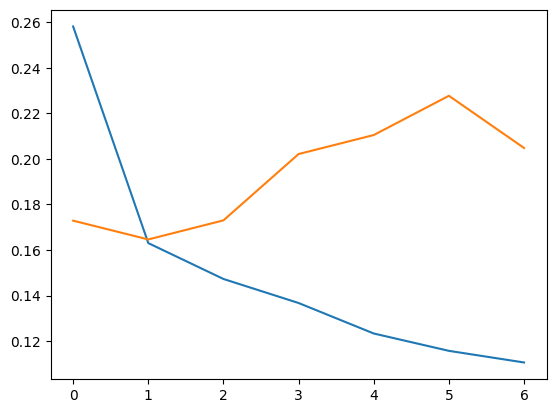

In [48]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.show()

#### Pytorch Implementation

In [55]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset , DataLoader
import copy

X_train_t = torch.tensor(X_train , dtype=torch.float32)
X_test_t = torch.tensor(X_test , dtype=torch.float32)

y_train_t = torch.tensor(y_train , dtype=torch.long)
y_test_t = torch.tensor(y_test , dtype=torch.long)


X_train_flat = X_train_t.reshape(
    X_train_t.shape[0] , -1
)
X_test_flat = X_test_t.reshape(
    X_test_t.shape[0] , -1
)


train_ds = TensorDataset(X_train_flat , y_train_t)

train_loader = DataLoader(
    train_ds , batch_size = 32 , shuffle = True
)


class MNIST_NN(nn.Module):

    def __init__(self , input_dim , num_classes):

        super().__init__()

        self.fc1 = nn.Linear(input_dim , 128)
        self.fc2 = nn.Linear(128 , num_classes)
        self.relu = nn.ReLU()

    def forward(self , x):

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

MNIST_NN_Model = MNIST_NN(input_dim = X_train_flat.shape[1] , num_classes = 10)


# Loss + Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    MNIST_NN_Model.parameters(),
    lr = 0.01
)

epochs = 10
patience = 5
best_val_loss = float('inf')
patience_counter = 0
best_weights = None

for epoch in range(epochs):
    MNIST_NN_Model.train()
    train_loss = 0.0

    for X_batch , y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = MNIST_NN_Model(X_batch)
        loss = criterion(y_pred , y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    MNIST_NN_Model.eval()
    with torch.no_grad():
        val_pred = MNIST_NN_Model(X_test_flat)
        val_loss = criterion(val_pred , y_test_t).item()

    print(f"Epoch {epoch+1}/{epochs} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_weights = copy.deepcopy(MNIST_NN_Model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

MNIST_NN_Model.load_state_dict(best_weights)

from sklearn.metrics import classification_report, confusion_matrix

MNIST_NN_Model.eval()
with torch.no_grad():
    y_test_logits = MNIST_NN_Model(X_test_flat)
    y_test_pred = torch.argmax(y_test_logits, dim=1)


Epoch 1/10 - train_loss: 0.2423 - val_loss: 0.1634
Epoch 2/10 - train_loss: 0.1628 - val_loss: 0.1976
Epoch 3/10 - train_loss: 0.1458 - val_loss: 0.1789
Epoch 4/10 - train_loss: 0.1295 - val_loss: 0.1914
Epoch 5/10 - train_loss: 0.1230 - val_loss: 0.2277
Epoch 6/10 - train_loss: 0.1167 - val_loss: 0.2043
Early stopping at epoch 6


In [56]:
accuracy = (y_test_pred == y_test_t).float().mean()
print(f"\nTest Accuracy: {accuracy.item():.4f}")
print(classification_report(y_test_t.numpy(), y_test_pred.numpy()))


Test Accuracy: 0.9541
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       980
           1       0.99      0.96      0.98      1135
           2       0.96      0.96      0.96      1032
           3       0.98      0.91      0.94      1010
           4       0.96      0.96      0.96       982
           5       0.90      0.97      0.93       892
           6       0.95      0.96      0.96       958
           7       0.95      0.96      0.96      1028
           8       0.92      0.95      0.94       974
           9       0.95      0.94      0.94      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000

